<a href="https://colab.research.google.com/github/ebuehrle/queens/blob/main/queens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

In [2]:
N = 8

In [3]:
queens = cp.Variable((N, N), boolean=True)

In [4]:
p = cp.Problem(cp.Minimize(0), [
    cp.sum(queens) >= N, # place N queens
    cp.sum(queens, axis=0) <= 1,  # at most one per row
    cp.sum(queens, axis=1) <= 1,  # at most one per column
    *[cp.diag(queens, k).sum() <= 1 for k in range(-N+1, N)], # at most one per diagonal
    *[cp.diag(queens[::-1, :], k).sum() <= 1 for k in range(-N+1, N)], # at most one per antidiagonal
])

In [5]:
p.solve(verbose=True, solver=cp.HIGHS)

(CVXPY) Jul 31 04:16:15 PM: Your problem has 64 variables, 47 constraints, and 0 parameters.
(CVXPY) Jul 31 04:16:15 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 31 04:16:15 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 31 04:16:15 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 31 04:16:15 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 31 04:16:15 PM: Compiling problem (target solver=HIGHS).
(CVXPY) Jul 31 04:16:15 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> HIGHS
(CVXPY) Jul 31 04:16:15 PM: Applying reduction Dcp2Cone
(CVXPY) Jul 31 04:16:15 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 31 04:16:15 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Jul 31 04:16:15 PM: Applying reduction HIGHS
(CVXPY) Jul 31 04:16:15 PM: Finished problem compilation (took

                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Jul 31 04:16:16 PM: Problem status: optimal
(CVXPY) Jul 31 04:16:16 PM: Optimal value: 0.000e+00
(CVXPY) Jul 31 04:16:16 PM: Compilation took 1.735e-01 seconds
(CVXPY) Jul 31 04:16:16 PM: Solver (including time spent in interface) took 1.001e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


0.0

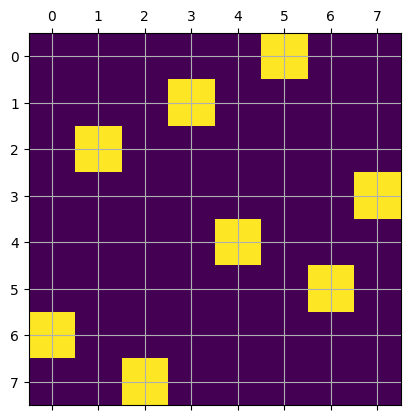

In [6]:
plt.matshow(queens.value)
plt.grid()